# Exercise 2 — Image Classification (From Scratch)
### Animal Face Classifier

---

## The Problem

A wildlife monitoring platform needs to automatically tag camera trap images
by animal type. You have been given a dataset of high-quality animal face
photographs across three categories: **cat, dog, and wild**.

Build an image classifier from scratch — no pretrained models.
The network must learn everything from the pixel data alone.

---

## The Data

```python
!pip install opendatasets --quiet
import opendatasets as od
od.download("https://www.kaggle.com/datasets/andrewmvd/animal-faces")
```

Images are organized in folders by class label under a nested directory structure.
You will need to walk the directory yourself to build your dataset.

⚠️ **One thing worth knowing:** images vary in size.
Your model needs a fixed input size — you decide what that is.

---

## What You Need to Deliver

A working Colab notebook that contains:

1. **A trained CNN** built from scratch in PyTorch that classifies animal faces
2. **A visualization** — a grid of sample images from the dataset with their labels
3. **A training report** — loss and accuracy curves for train and validation
4. **A test accuracy score**
5. **A live inference demo** — given any image file, the model returns the predicted animal

Your CNN must be built using `nn.Module` with convolutional layers.
`torchvision.models` pretrained weights are not allowed here — that is Exercise 3.

---

In [1]:
import pandas as pd
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import datasets, transforms
from PIL import Image
import random
import kagglehub
from typing import Tuple, Dict, List
import gradio as gr
import torch.nn.functional as F


# --- Master Configuration ---
CONFIG = {
    "dataset_name": "andrewmvd/animal-faces",
    "img_size": 128,          # We can try 128 or 256
    "batch_size": 64,
    "learning_rate": 1e-3,
    "num_epochs": 30,
    "dropout_rate": 0.3,
    "weight_decay": 1e-5,
    "train_split": 0.85,
    "seed": 42,
    "num_workers": 2,
    "patience": 7             # Early stopping: stop if val_loss doesn't improve for 7 epochs
}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(CONFIG['seed'])
print(f"🚀 Using device: {DEVICE}")
print(f"🖼️ Image resolution set to: {CONFIG['img_size']}x{CONFIG['img_size']}")

🚀 Using device: cuda
🖼️ Image resolution set to: 128x128


In [2]:
def download_kaggle_dataset(dataset_name: str) -> str:

  print(f"Downloading dataset '{dataset_name}' using kagglehub...")
  path = kagglehub.dataset_download(dataset_name)
  print(f"✅ Dataset available at: {path}")
  return path

dataset_path = download_kaggle_dataset(CONFIG['dataset_name'])
!cd {dataset_path} && ls -l

Using Colab cache for faster access to the 'animal-faces' dataset.
✅ Dataset available at: /kaggle/input/animal-faces
total 0
drwxr-sr-x 4 1000 1000 0 Jun 14 17:18 afhq


## Step 2: Exploratory Data Analysis (EDA) & Visualization
In this step, we will explore the dataset structure, verify class counts, and visualize some sample images.

In [3]:
from PIL import Image
import random

# 1. Define Paths
base_path = Path(dataset_path) / "afhq"
train_path = base_path / "train"
val_path = base_path / "val"

def count_images(path):
    counts = {}
    for cls in os.listdir(path):
        if os.path.isdir(path / cls):
            counts[cls] = len(os.listdir(path / cls))
    return counts

print("📊 Class Distribution:")
train_counts = count_images(train_path)
val_counts = count_images(val_path)

print(f"  Training: {train_counts}")
print(f"  Validation: {val_counts}")

# 2. Check Image Dimensions
sample_cls = list(train_counts.keys())[0]
sample_img_path = next((train_path / sample_cls).iterdir())
with Image.open(sample_img_path) as img:
    print(f"\n📏 Sample Image Resolution: {img.size} ({img.mode})")

📊 Class Distribution:
  Training: {'dog': 4739, 'wild': 4738, 'cat': 5153}
  Validation: {'dog': 500, 'wild': 500, 'cat': 500}

📏 Sample Image Resolution: (512, 512) (RGB)


🖼️ Visualizing Random Samples from Training Set:


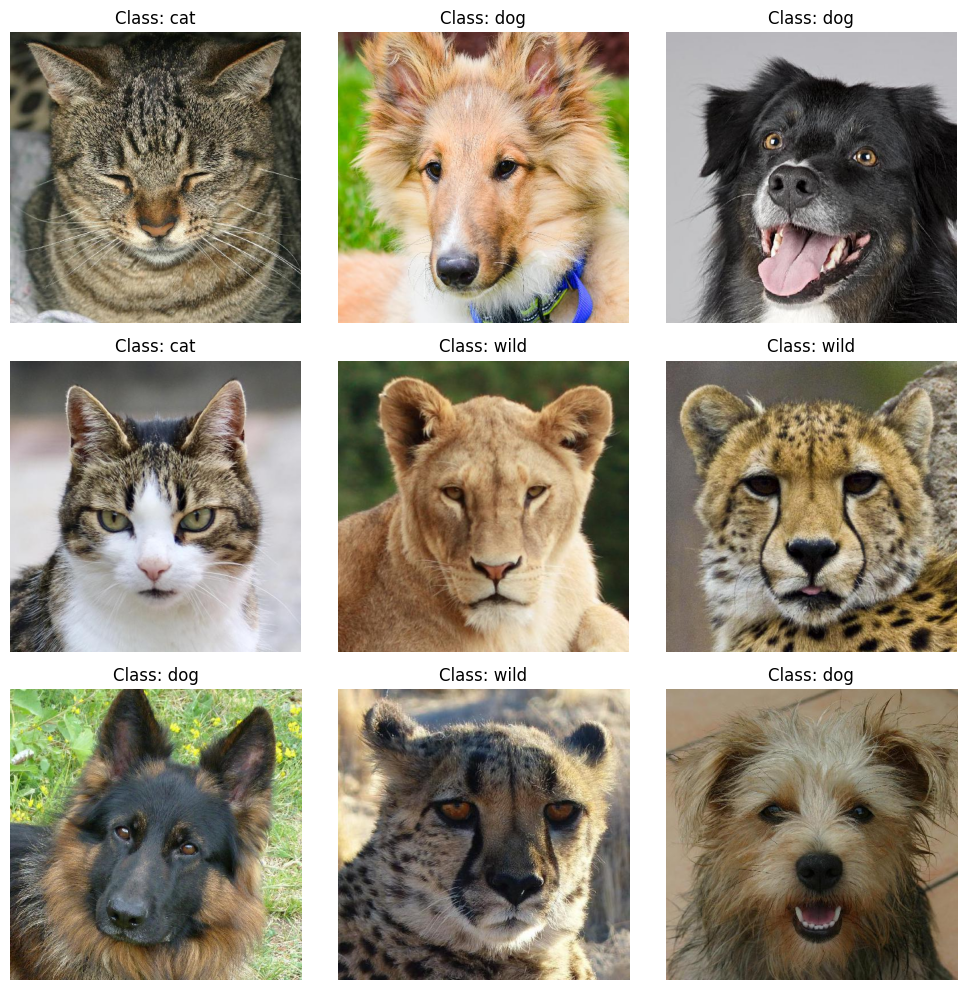

In [4]:
def plot_samples(path, num_samples=9):
    classes = sorted([c for c in os.listdir(path) if os.path.isdir(path / c)])
    fig, axes = plt.subplots(3, 3, figsize=(10, 10))
    
    for i, ax in enumerate(axes.flat):
        # Pick a random class
        cls = random.choice(classes)
        # Pick a random image from that class
        img_name = random.choice(os.listdir(path / cls))
        img_path = path / cls / img_name
        
        img = Image.open(img_path)
        ax.imshow(img)
        ax.set_title(f"Class: {cls}")
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()

print("🖼️ Visualizing Random Samples from Training Set:")
plot_samples(train_path)

## Step 3: Image Transformations, Dataset & DataLoader
We will now define the transformations (including augmentation for training) and create our split datasets.

In [5]:
# 1. Define Transformations
train_transform = transforms.Compose([
    transforms.Resize((CONFIG['img_size'], CONFIG['img_size'])),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((CONFIG['img_size'], CONFIG['img_size'])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 2. Load Full Dataset and Split Train/Val
full_train_dataset = datasets.ImageFolder(root=train_path, transform=train_transform)

train_size = int(CONFIG['train_split'] * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_train_dataset, 
    [train_size, val_size],
    generator=torch.Generator().manual_seed(CONFIG['seed'])
)

# 3. Load Test Dataset (The original val folder)
test_dataset = datasets.ImageFolder(root=val_path, transform=test_transform)

# 4. Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True, num_workers=CONFIG['num_workers'])
val_loader = DataLoader(val_dataset, batch_size=CONFIG['batch_size'], shuffle=False, num_workers=CONFIG['num_workers'])
test_loader = DataLoader(test_dataset, batch_size=CONFIG['batch_size'], shuffle=False, num_workers=CONFIG['num_workers'])

print(f"✅ Datasets ready!")
print(f"   - Training samples: {len(train_dataset)}")
print(f"   - Validation samples: {len(val_dataset)}")
print(f"   - Test samples: {len(test_dataset)}")
print(f"   - Classes: {full_train_dataset.classes}")

✅ Datasets ready!
   - Training samples: 12435
   - Validation samples: 2195
   - Test samples: 1500
   - Classes: ['cat', 'dog', 'wild']


## Step 4: CNN Model Architecture (Mini-ResNet from Scratch)
We will implement a custom Residual Network. This architecture uses skip-connections to improve gradient flow, allowing us to train a deeper model effectively without pretrained weights.

In [6]:
class ResidualBlock(nn.Module):
    """A standard Residual Block with two convolutional layers and a skip connection."""
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        # If stride != 1 or input channels != output channels, we need a projection (1x1 conv) for the skip connection
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)  # The Skip Connection
        out = self.relu(out)
        return out

class AnimalClassifier(nn.Module):
    def __init__(self, num_classes=3, dropout_rate=0.3):
        super(AnimalClassifier, self).__init__()
        self.in_channels = 32
        
        # Initial Layer
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(32)
        self.relu = nn.ReLU(inplace=True)
        
        # ResNet Layers
        self.layer1 = self._make_layer(32, 1)  # Output: 32x128x128
        self.layer2 = self._make_layer(64, 2)  # Output: 64x64x64
        self.layer3 = self._make_layer(128, 2) # Output: 128x32x32
        self.layer4 = self._make_layer(256, 2) # Output: 256x16x16
        
        # Final Layers
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1)) # Guarantees 1x1 output regardless of input size
        self.dropout = nn.Dropout(dropout_rate)
        self.fc = nn.Linear(256, num_classes)
        
    def _make_layer(self, out_channels, stride):
        layer = ResidualBlock(self.in_channels, out_channels, stride)
        self.in_channels = out_channels
        return layer
    
    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = self.fc(x)
        return x

# Instantiate Model
model = AnimalClassifier(num_classes=len(full_train_dataset.classes), dropout_rate=CONFIG['dropout_rate']).to(DEVICE)
print(f"✅ Mini-ResNet model instantiated and moved to {DEVICE}")

# Calculate number of parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"🔢 Total Parameters: {total_params:,}")

✅ Mini-ResNet model instantiated and moved to cuda
🔢 Total Parameters: 1,227,171


## Step 5: The Training Loop 


In [7]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs, patience):
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_loss = float('inf')
    epochs_no_improve = 0
    
    for epoch in range(num_epochs):
        # --- Training Phase ---
        model.train()
        train_loss, train_correct = 0.0, 0
        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            train_correct += (predicted == labels).sum().item()
        
        # Step the scheduler
        scheduler.step()
        
        # --- Validation Phase ---
        model.eval()
        val_loss, val_correct = 0.0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                val_correct += (predicted == labels).sum().item()
        
        # Calculate metrics
        epoch_train_loss = train_loss / len(train_loader.dataset)
        epoch_train_acc = train_correct / len(train_loader.dataset)
        epoch_val_loss = val_loss / len(val_loader.dataset)
        epoch_val_acc = val_correct / len(val_loader.dataset)
        
        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc)
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc)
        
        print(f"Epoch {epoch+1}/{num_epochs} | "
              f"Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.4f} | "
              f"Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.4f}")
        
        # --- Early Stopping Logic ---
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            epochs_no_improve = 0
            # Save the best model state
            torch.save(model.state_dict(), 'best_model.pth')
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"🛑 Early stopping triggered after {epoch+1} epochs!")
                break
                
    return history

# 1. Setup Training Components
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=CONFIG['learning_rate'], weight_decay=CONFIG['weight_decay'])
scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=CONFIG['learning_rate'], 
                                          steps_per_epoch=len(train_loader), epochs=CONFIG['num_epochs'])

# 2. Start Training
print("🏗️ Starting Training Loop...")
history = train_model(
    model, train_loader, val_loader, criterion, optimizer, scheduler, 
    num_epochs=CONFIG['num_epochs'], patience=CONFIG['patience']
)

🏗️ Starting Training Loop...
Epoch 1/30 | Train Loss: 0.8812 Acc: 0.5645 | Val Loss: 0.8197 Acc: 0.6159
Epoch 2/30 | Train Loss: 0.7498 Acc: 0.6629 | Val Loss: 0.7017 Acc: 0.6948
Epoch 3/30 | Train Loss: 0.6376 Acc: 0.7301 | Val Loss: 0.5882 Acc: 0.7695
Epoch 4/30 | Train Loss: 0.5444 Acc: 0.7801 | Val Loss: 0.5454 Acc: 0.7777
Epoch 5/30 | Train Loss: 0.4815 Acc: 0.8121 | Val Loss: 0.4574 Acc: 0.8214
Epoch 6/30 | Train Loss: 0.4399 Acc: 0.8331 | Val Loss: 0.4888 Acc: 0.7968
Epoch 7/30 | Train Loss: 0.4104 Acc: 0.8450 | Val Loss: 0.5181 Acc: 0.7786
Epoch 8/30 | Train Loss: 0.3738 Acc: 0.8588 | Val Loss: 0.3587 Acc: 0.8620
Epoch 9/30 | Train Loss: 0.3486 Acc: 0.8708 | Val Loss: 0.4110 Acc: 0.8401
Epoch 10/30 | Train Loss: 0.3221 Acc: 0.8815 | Val Loss: 0.3245 Acc: 0.8774
Epoch 11/30 | Train Loss: 0.3019 Acc: 0.8889 | Val Loss: 0.2972 Acc: 0.8943
Epoch 12/30 | Train Loss: 0.2813 Acc: 0.8988 | Val Loss: 0.2837 Acc: 0.8911
Epoch 13/30 | Train Loss: 0.2765 Acc: 0.9020 | Val Loss: 0.2469 Acc:

#   plots for Loss and Accuracy to visualize the learning process.


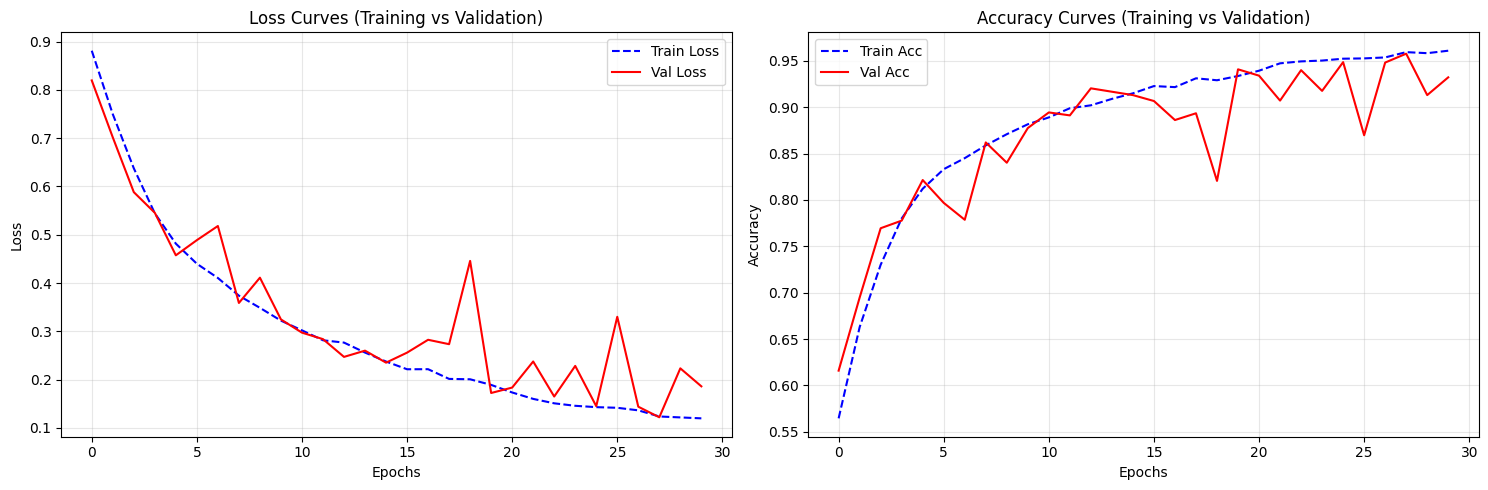

In [ ]:

    # --- Step 6: Evaluation & Training Report ---
    
def plot_training_history(history):
         fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
         # 1. Loss Plot
         ax1.plot(history['train_loss'], label='Train Loss', color='blue', linestyle='--')
         ax1.plot(history['val_loss'], label='Val Loss', color='red')
         ax1.set_title('Loss Curves (Training vs Validation)')
         ax1.set_xlabel('Epochs')
         ax1.set_ylabel('Loss')
         ax1.legend()
         ax1.grid(True, alpha=0.3)
    
        # 2. Accuracy Plot
         ax2.plot(history['train_acc'], label='Train Acc', color='blue', linestyle='--')
         ax2.plot(history['val_acc'], label='Val Acc', color='red')
         ax2.set_title('Accuracy Curves (Training vs Validation)')
         ax2.set_xlabel('Epochs')
         ax2.set_ylabel('Accuracy')
         ax2.legend()
         ax2.grid(True, alpha=0.3)
  
         plt.tight_layout()
         plt.show()
  
   # Run the plotting function
plot_training_history(history)


# Final Test Evaluation


In [ ]:
 # --- Final Test Accuracy Score ---
    
     # 1. Load the best weights saved during training
model.load_state_dict(torch.load('best_model.pth'))
model.eval()
test_correct = 0
test_total = 0
print("🔍 Evaluating on the held-out Test Set...")
with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            test_total += labels.size(0)
            test_correct += (predicted == labels).sum().item()
test_acc = test_correct / test_total
print(f"\n✨ Final Test Accuracy: {test_acc:.4f}")
print(f"🎯 Target Accuracy: ≥ 0.75")
print(f"Result: {'✅ SUCCESS' if test_acc >= 0.75 else '❌ NEED MORE TRAINING'}")


🔍 Evaluating on the held-out Test Set...

✨ Final Test Accuracy: 0.9647
🎯 Target Accuracy: ≥ 0.75
Result: ✅ SUCCESS


#  Live Inference Demo

In [ ]:
def predict_image(img):
    if img is None:
        return None
        
    model.eval()
    img_tensor = test_transform(img).unsqueeze(0).to(DEVICE)
    
    with torch.no_grad():
        outputs = model(img_tensor)
        # We move probabilities to CPU before converting to Python floats
        probabilities = F.softmax(outputs, dim=1).cpu()
    
    class_names = full_train_dataset.classes
    # probabilities[i].item() is the safe way to get the float value
    return {class_names[i]: float(probabilities[i].item()) for i in range(len(class_names))}

# UI with Gradio Blocks
with gr.Blocks(theme=gr.themes.Soft(), css=".gradio-container {background-color: #f8f9fa}") as demo:
    gr.Markdown("# 🐾 Animal Face Classifier")
    
    with gr.Row():
        with gr.Column():
            image_input = gr.Image(type="pil", label="Upload Animal Face")
            predict_btn = gr.Button("🚀 Classify Animal", variant="primary")
            
        with gr.Column():
            label_output = gr.Label(num_top_classes=3, label="Model Prediction")
            
    predict_btn.click(
        fn=predict_image,
        inputs=image_input,
        outputs=label_output
    )

# Launch
print("🌐 Launching the beautiful demo...")
demo.launch(debug=False, share=True)